**Cell 1: build the sparse noisy dataset**

In [7]:
import numpy as np, scipy.io, urllib.request, os

URL = "https://raw.githubusercontent.com/maziarraissi/PINNs/master/appendix/Data/burgers_shock.mat"
if not os.path.exists("burgers_shock.mat"):
    urllib.request.urlretrieve(URL, "burgers_shock.mat")

d = scipy.io.loadmat("burgers_shock.mat")
x = d['x'].flatten()          # (256,)
t = d['t'].flatten()          # (100,)
u_ref = np.real(d['usol'])    # (256,100): rows=x, cols=t
print(x.shape, t.shape, u_ref.shape, t.max())

(256,) (100,) (256, 100) 0.99


torch.Size([2000, 1]) noise rms: 0.006157152749919912


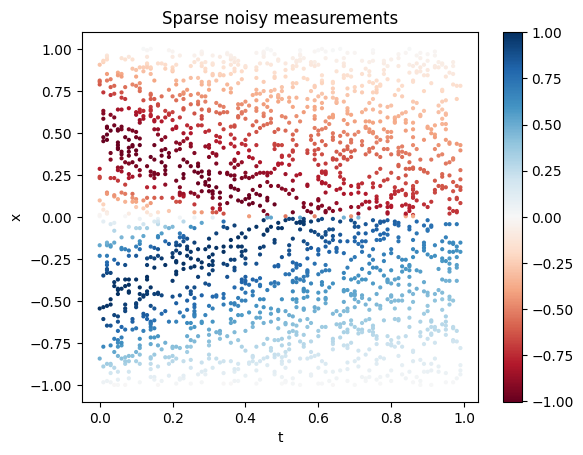

In [8]:
import numpy as np, torch, matplotlib.pyplot as plt

N_DATA, NOISE = 2000, 0.01          # 2000 sensors, noise = 1% of std(u)
rng = np.random.default_rng(0)

X, T = np.meshgrid(x, t, indexing='ij')          # (256,100), matches u_ref layout
idx = rng.choice(X.size, N_DATA, replace=False)  # random space-time "sensor" locations
x_d, t_d, u_d = X.ravel()[idx], T.ravel()[idx], u_ref.ravel()[idx]
u_noisy = u_d + NOISE*u_ref.std()*rng.standard_normal(N_DATA)

# to (N,1) float32 tensors
to_t = lambda a: torch.tensor(a, dtype=torch.float32).reshape(-1,1)
x_d, t_d, u_d_t = to_t(x_d), to_t(t_d), to_t(u_noisy)

print(x_d.shape, "noise rms:", np.sqrt(np.mean((u_noisy-u_d)**2)))
plt.scatter(t_d, x_d, c=u_d_t, s=4, cmap='RdBu'); plt.xlabel('t'); plt.ylabel('x')
plt.title('Sparse noisy measurements'); plt.colorbar(); plt.show()

**Cell 2: model with learnable λ1 and λ2**

In [9]:
import torch, torch.nn as nn
torch.manual_seed(0)
dev = 'cuda' if torch.cuda.is_available() else 'cpu'

class InvPINN(nn.Module):
    def __init__(self, hidden=20, layers=8):
        super().__init__()
        dims = [2] + [hidden]*layers + [1]
        self.net = nn.ModuleList(nn.Linear(a, b) for a, b in zip(dims[:-1], dims[1:]))
        for l in self.net: nn.init.xavier_normal_(l.weight); nn.init.zeros_(l.bias)
        self.lam1 = nn.Parameter(torch.tensor(0.0))   # true 1.0
        self.p    = nn.Parameter(torch.tensor(1.0))   # lam2 = 0.01*p, true p = 0.3183
    @property
    def lam2(self): return 0.01 * self.p
    def forward(self, x, t):
        h = torch.cat([x, t], 1)
        for l in self.net[:-1]: h = torch.tanh(l(h))
        return self.net[-1](h)

def derivs(model, x, t):
    x = x.clone().requires_grad_(True); t = t.clone().requires_grad_(True)
    u = model(x, t)
    g = lambda f, v: torch.autograd.grad(f, v, torch.ones_like(f), create_graph=True)[0]
    u_t, u_x = g(u, t), g(u, x)
    return u, u_t, u_x, g(u_x, x)

model = InvPINN().to(dev)
# data (from Step 1) and collocation points
xd, td, ud = x_d.to(dev), t_d.to(dev), u_d_t.to(dev)
N_F = 10000
xf = (2*torch.rand(N_F, 1) - 1).to(dev); tf = torch.rand(N_F, 1).to(dev)

W_DATA, W_PDE = 10.0, 1.0
def losses():
    u = model(xd, td)
    l_data = ((u - ud)**2).mean()
    _, u_t, u_x, u_xx = derivs(model, xf, tf)
    uf = model(xf, tf)
    res = u_t + model.lam1*uf*u_x - model.lam2*u_xx
    return l_data, (res**2).mean()

ld, lp = losses()
print("params:", sum(p.numel() for p in model.parameters()))
print(f"data {ld.item():.4f}  pde {lp.item():.2e}  lam1 {model.lam1.item():.3f}  lam2 {model.lam2.item():.5f}")

params: 3023
data 0.3537  pde 3.64e-03  lam1 0.000  lam2 0.01000


**Cell 3: train with Adam and log the λ's**

In [10]:
import time
def losses():
    l_data = ((model(xd, td) - ud)**2).mean()
    u, u_t, u_x, u_xx = derivs(model, xf, tf)       # u reused, no 2nd forward pass
    res = u_t + model.lam1*u*u_x - model.lam2*u_xx
    return l_data, (res**2).mean()

opt = torch.optim.Adam(model.parameters(), lr=1e-3)   # includes lam1 and p
sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9997)
hist = {'data':[], 'pde':[], 'lam1':[], 'lam2':[]}
TRUE1, TRUE2 = 1.0, 0.01/np.pi

t0 = time.time()
for it in range(1, 10001):
    opt.zero_grad()
    ld, lp = losses()
    (W_DATA*ld + W_PDE*lp).backward()
    opt.step(); sched.step()
    hist['data'].append(ld.item()); hist['pde'].append(lp.item())
    hist['lam1'].append(model.lam1.item()); hist['lam2'].append(model.lam2.item())
    if it % 1000 == 0:
        e1 = abs(model.lam1.item()-TRUE1)/TRUE1*100
        e2 = abs(model.lam2.item()-TRUE2)/TRUE2*100
        print(f"{it:5d} data {ld.item():.2e} pde {lp.item():.2e} "
              f"lam1 {model.lam1.item():.4f} ({e1:.1f}%) lam2 {model.lam2.item():.5f} ({e2:.1f}%)")
print(f"{time.time()-t0:.0f}s")

 1000 data 2.16e-03 pde 9.85e-03 lam1 0.6743 (32.6%) lam2 0.00499 (56.6%)
 2000 data 3.62e-04 pde 2.82e-03 lam1 0.8919 (10.8%) lam2 0.00410 (28.9%)
 3000 data 1.29e-04 pde 1.57e-03 lam1 0.9593 (4.1%) lam2 0.00371 (16.6%)
 4000 data 8.00e-05 pde 1.05e-03 lam1 0.9795 (2.1%) lam2 0.00353 (11.0%)
 5000 data 6.15e-05 pde 7.65e-04 lam1 0.9870 (1.3%) lam2 0.00344 (8.0%)
 6000 data 5.25e-05 pde 5.94e-04 lam1 0.9907 (0.9%) lam2 0.00338 (6.1%)
 7000 data 4.77e-05 pde 4.79e-04 lam1 0.9928 (0.7%) lam2 0.00334 (5.0%)
 8000 data 4.49e-05 pde 3.98e-04 lam1 0.9943 (0.6%) lam2 0.00332 (4.2%)
 9000 data 4.31e-05 pde 3.39e-04 lam1 0.9953 (0.5%) lam2 0.00330 (3.6%)
10000 data 4.20e-05 pde 3.08e-04 lam1 0.9960 (0.4%) lam2 0.00329 (3.2%)
146s


**Cell 4: convergence plot and validation**

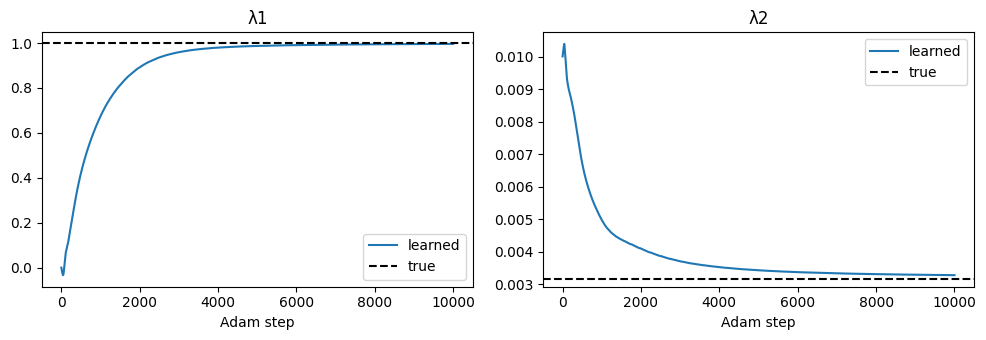

relL2 all 0.0039 | off-shock 0.0031 | max err 0.0327
lam1 0.9960 lam2 0.00329 (true 1, 0.00318)


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
it = np.arange(1, len(hist['lam1'])+1)
for a, k, tr, nm in [(ax[0],'lam1',TRUE1,'λ1'), (ax[1],'lam2',TRUE2,'λ2')]:
    a.plot(it, hist[k], label='learned'); a.axhline(tr, ls='--', c='k', label='true')
    a.set_title(nm); a.set_xlabel('Adam step'); a.legend()
plt.tight_layout(); plt.savefig('param_convergence.png', dpi=150); plt.show()

# validation on the full 256x100 grid
with torch.no_grad():
    u_pred = model(to_t(X.ravel()).to(dev), to_t(T.ravel()).to(dev)).cpu().numpy().reshape(X.shape)
rel = lambda a, b: np.linalg.norm(a-b)/np.linalg.norm(b)
m = np.abs(X) > 0.05
print(f"relL2 all {rel(u_pred,u_ref):.4f} | off-shock {rel(u_pred[m],u_ref[m]):.4f} | max err {np.abs(u_pred-u_ref).max():.4f}")
print(f"lam1 {model.lam1.item():.4f} lam2 {model.lam2.item():.5f} (true 1, {TRUE2:.5f})")

**Cell 5: does λ2 keep converging?**

In [12]:
opt = torch.optim.Adam(model.parameters(), lr=3e-4)   # fresh Adam, small lr (avoids the P3 "kick")
for it in range(1, 5001):
    opt.zero_grad()
    ld, lp = losses()
    (W_DATA*ld + W_PDE*lp).backward()
    opt.step()
    hist['data'].append(ld.item()); hist['pde'].append(lp.item())
    hist['lam1'].append(model.lam1.item()); hist['lam2'].append(model.lam2.item())
    if it % 1000 == 0:
        e2 = abs(model.lam2.item()-TRUE2)/TRUE2*100
        print(f"{it:5d} data {ld.item():.2e} pde {lp.item():.2e} lam1 {model.lam1.item():.4f} lam2 {model.lam2.item():.5f} ({e2:.1f}%)")
with torch.no_grad():
    u_pred = model(to_t(X.ravel()).to(dev), to_t(T.ravel()).to(dev)).cpu().numpy().reshape(X.shape)
print(f"relL2 {rel(u_pred,u_ref):.4f}")

 1000 data 4.17e-05 pde 2.75e-04 lam1 0.9962 lam2 0.00329 (3.3%)
 2000 data 4.09e-05 pde 2.44e-04 lam1 0.9967 lam2 0.00328 (2.9%)
 3000 data 5.60e-05 pde 2.96e-04 lam1 0.9970 lam2 0.00327 (2.9%)
 4000 data 4.01e-05 pde 1.92e-04 lam1 0.9972 lam2 0.00327 (2.7%)
 5000 data 3.98e-05 pde 1.73e-04 lam1 0.9971 lam2 0.00326 (2.6%)
relL2 0.0029


**Cell 6: final figures and README**

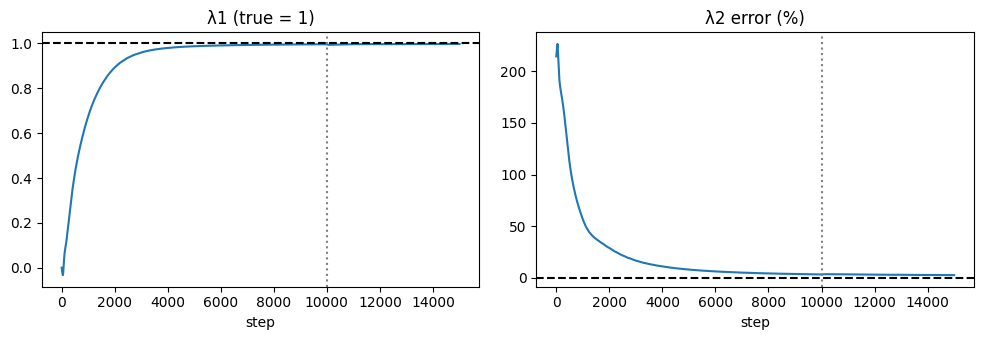

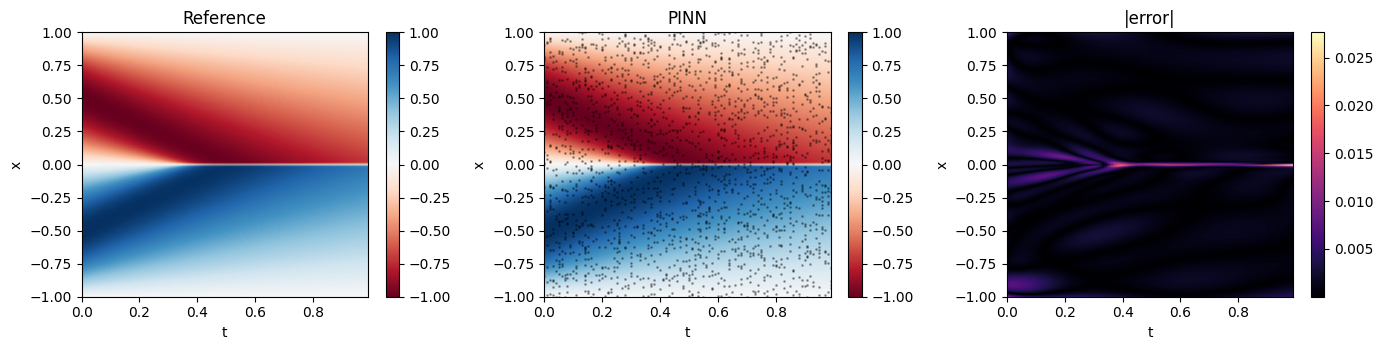

saved; lam1 0.9971 lam2 0.00326


In [14]:
import os; os.makedirs('project4/figures', exist_ok=True)
it = np.arange(1, len(hist['lam1'])+1)

# 1) parameter convergence, % error on log axis
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(it, hist['lam1']); ax[0].axhline(TRUE1, ls='--', c='k'); ax[0].set_title('λ1 (true = 1)')
ax[1].plot(it, np.array(hist['lam2'])/TRUE2*100-100); ax[1].axhline(0, ls='--', c='k')
ax[1].set_title('λ2 error (%)')
for a in ax: a.axvline(10000, c='gray', ls=':'); a.set_xlabel('step')
plt.tight_layout(); plt.savefig('project4/figures/param_convergence.png', dpi=150); plt.show()

# 2) reference vs PINN vs error, with sensors overlaid
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ext = [t.min(), t.max(), x.min(), x.max()]
for a, f, ttl, cm, kw in [(ax[0], u_ref, 'Reference', 'RdBu', dict(vmin=-1, vmax=1)),
                          (ax[1], u_pred, 'PINN', 'RdBu', dict(vmin=-1, vmax=1)),
                          (ax[2], np.abs(u_pred-u_ref), '|error|', 'magma', {})]:
    im = a.imshow(f, extent=ext, origin='lower', aspect='auto', cmap=cm, **kw)
    a.set_title(ttl); a.set_xlabel('t'); a.set_ylabel('x'); plt.colorbar(im, ax=a)
ax[1].scatter(t_d.numpy(), x_d.numpy(), s=1, c='k', alpha=0.3)
plt.tight_layout(); plt.savefig('project4/figures/pinn_vs_ref.png', dpi=150); plt.show()

torch.save(model.state_dict(), 'project4/pinn_inverse_final.pt')
print("saved; lam1", round(model.lam1.item(),4), "lam2", round(model.lam2.item(),5))